# INX Future Inc — Employee Performance Analysis
## Notebook 5: Results Visualization & Business Insights
**Project Code:** 10281 | **IABAC Certified Data Scientist Project**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
df = pd.read_excel('../../data/raw/INX_Future_Inc_Employee_Performance_CDS_Project2_Data_V1_8.xls')
with open('../../data/processed/best_model_rf.pkl','rb') as f: model = pickle.load(f)
with open('../../data/processed/feature_columns.pkl','rb') as f: feature_columns = pickle.load(f)
print('Setup complete')

Setup complete


## Business Requirement #1 — Department-wise Performance Dashboard

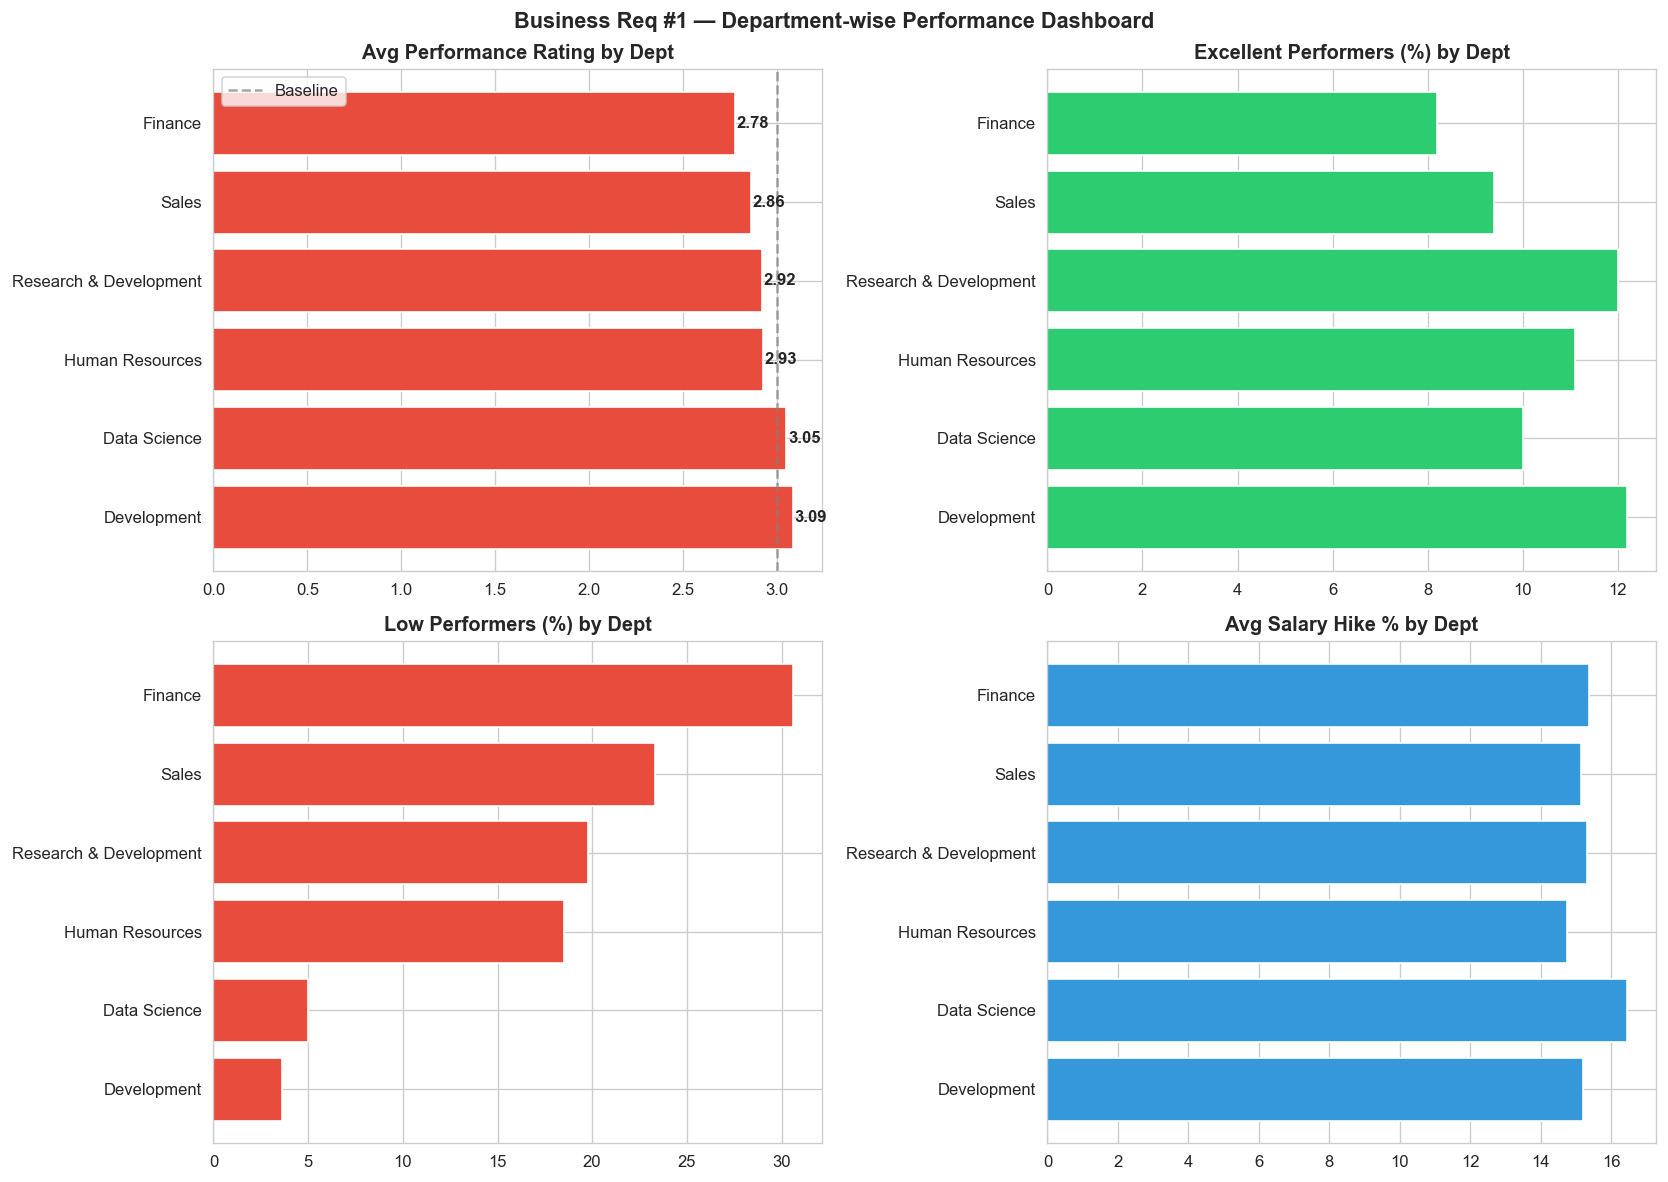

         EmpDepartment  Total  Avg_Perf  Excellent_pct  Low_pct
           Development    361  3.085873           12.2      3.6
          Data Science     20  3.050000           10.0      5.0
       Human Resources     54  2.925926           11.1     18.5
Research & Development    343  2.921283           12.0     19.8
                 Sales    373  2.860590            9.4     23.3
               Finance     49  2.775510            8.2     30.6


In [2]:
dept_stats = df.groupby('EmpDepartment').agg(
    Total=('PerformanceRating','count'),
    Avg_Perf=('PerformanceRating','mean'),
    Excellent=('PerformanceRating', lambda x: (x==4).sum()),
    Low=('PerformanceRating', lambda x: (x==2).sum()),
    Avg_Hike=('EmpLastSalaryHikePercent','mean')
).reset_index()
dept_stats['Excellent_pct'] = (dept_stats['Excellent']/dept_stats['Total']*100).round(1)
dept_stats['Low_pct'] = (dept_stats['Low']/dept_stats['Total']*100).round(1)
dept_stats = dept_stats.sort_values('Avg_Perf', ascending=False)

fig, axes = plt.subplots(2, 2, figsize=(14,10))
bars = axes[0,0].barh(dept_stats['EmpDepartment'], dept_stats['Avg_Perf'],
    color=['#2ecc71' if x>=3.1 else '#e74c3c' for x in dept_stats['Avg_Perf']])
axes[0,0].axvline(3.0, color='gray', linestyle='--', alpha=0.7, label='Baseline')
axes[0,0].set_title('Avg Performance Rating by Dept', fontweight='bold')
axes[0,0].legend()
for bar, val in zip(bars, dept_stats['Avg_Perf']):
    axes[0,0].text(bar.get_width()+0.01, bar.get_y()+bar.get_height()/2, f'{val:.2f}', va='center', fontweight='bold')
axes[0,1].barh(dept_stats['EmpDepartment'], dept_stats['Excellent_pct'], color='#2ecc71')
axes[0,1].set_title('Excellent Performers (%) by Dept', fontweight='bold')
axes[1,0].barh(dept_stats['EmpDepartment'], dept_stats['Low_pct'], color='#e74c3c')
axes[1,0].set_title('Low Performers (%) by Dept', fontweight='bold')
axes[1,1].barh(dept_stats['EmpDepartment'], dept_stats['Avg_Hike'], color='#3498db')
axes[1,1].set_title('Avg Salary Hike % by Dept', fontweight='bold')
plt.suptitle('Business Req #1 — Department-wise Performance Dashboard', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../../data/processed/fig_dept_dashboard.png', bbox_inches='tight')
plt.show()
print(dept_stats[['EmpDepartment','Total','Avg_Perf','Excellent_pct','Low_pct']].to_string(index=False))

## Business Requirement #2 — Top 3 Most Important Factors

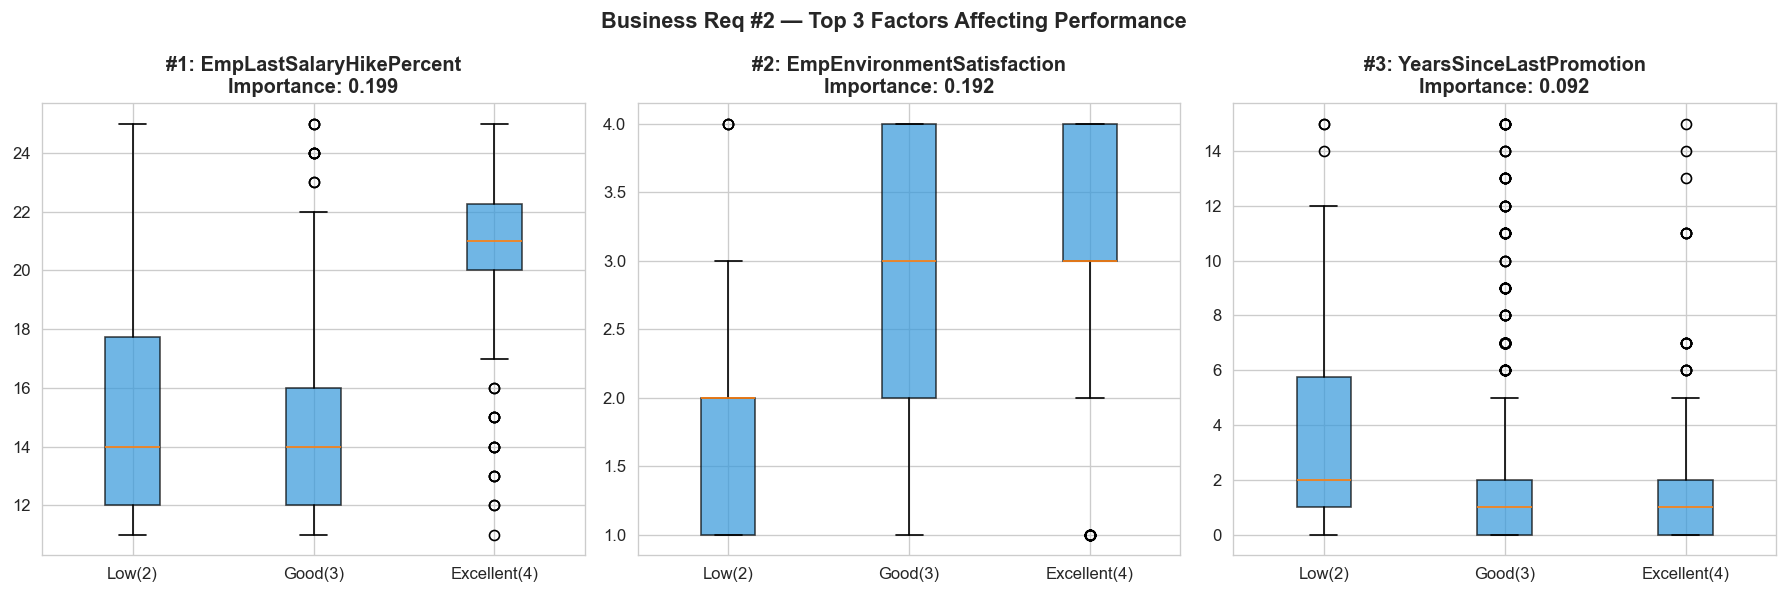


TOP 3 FACTORS:
1. EmpLastSalaryHikePercent: 19.87% importance
2. EmpEnvironmentSatisfaction: 19.19% importance
3. YearsSinceLastPromotion: 9.21% importance


In [3]:
importances = pd.Series(model.feature_importances_, index=feature_columns).sort_values(ascending=False)
top3 = importances.head(3)
fig, axes = plt.subplots(1, 3, figsize=(15,5))
for i, (feat, score) in enumerate(top3.items()):
    if feat in df.columns:
        data_plot = [df[df['PerformanceRating']==r][feat].values for r in [2,3,4]]
        axes[i].boxplot(data_plot, labels=['Low(2)','Good(3)','Excellent(4)'], patch_artist=True,
                        boxprops=dict(facecolor='#3498db', alpha=0.7))
        axes[i].set_title(f'#{i+1}: {feat}\nImportance: {score:.3f}', fontweight='bold')
    else:
        axes[i].bar(['Feature'], [score], color='#3498db')
        axes[i].set_title(f'#{i+1}: {feat}\nImportance: {score:.3f}', fontweight='bold')
plt.suptitle('Business Req #2 — Top 3 Factors Affecting Performance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../../data/processed/fig_top3_factors.png', bbox_inches='tight')
plt.show()
print('\nTOP 3 FACTORS:')
for i, (f, s) in enumerate(top3.items(), 1): print(f'{i}. {f}: {s*100:.2f}% importance')

## Business Requirement #4 — Drivers for Recommendations

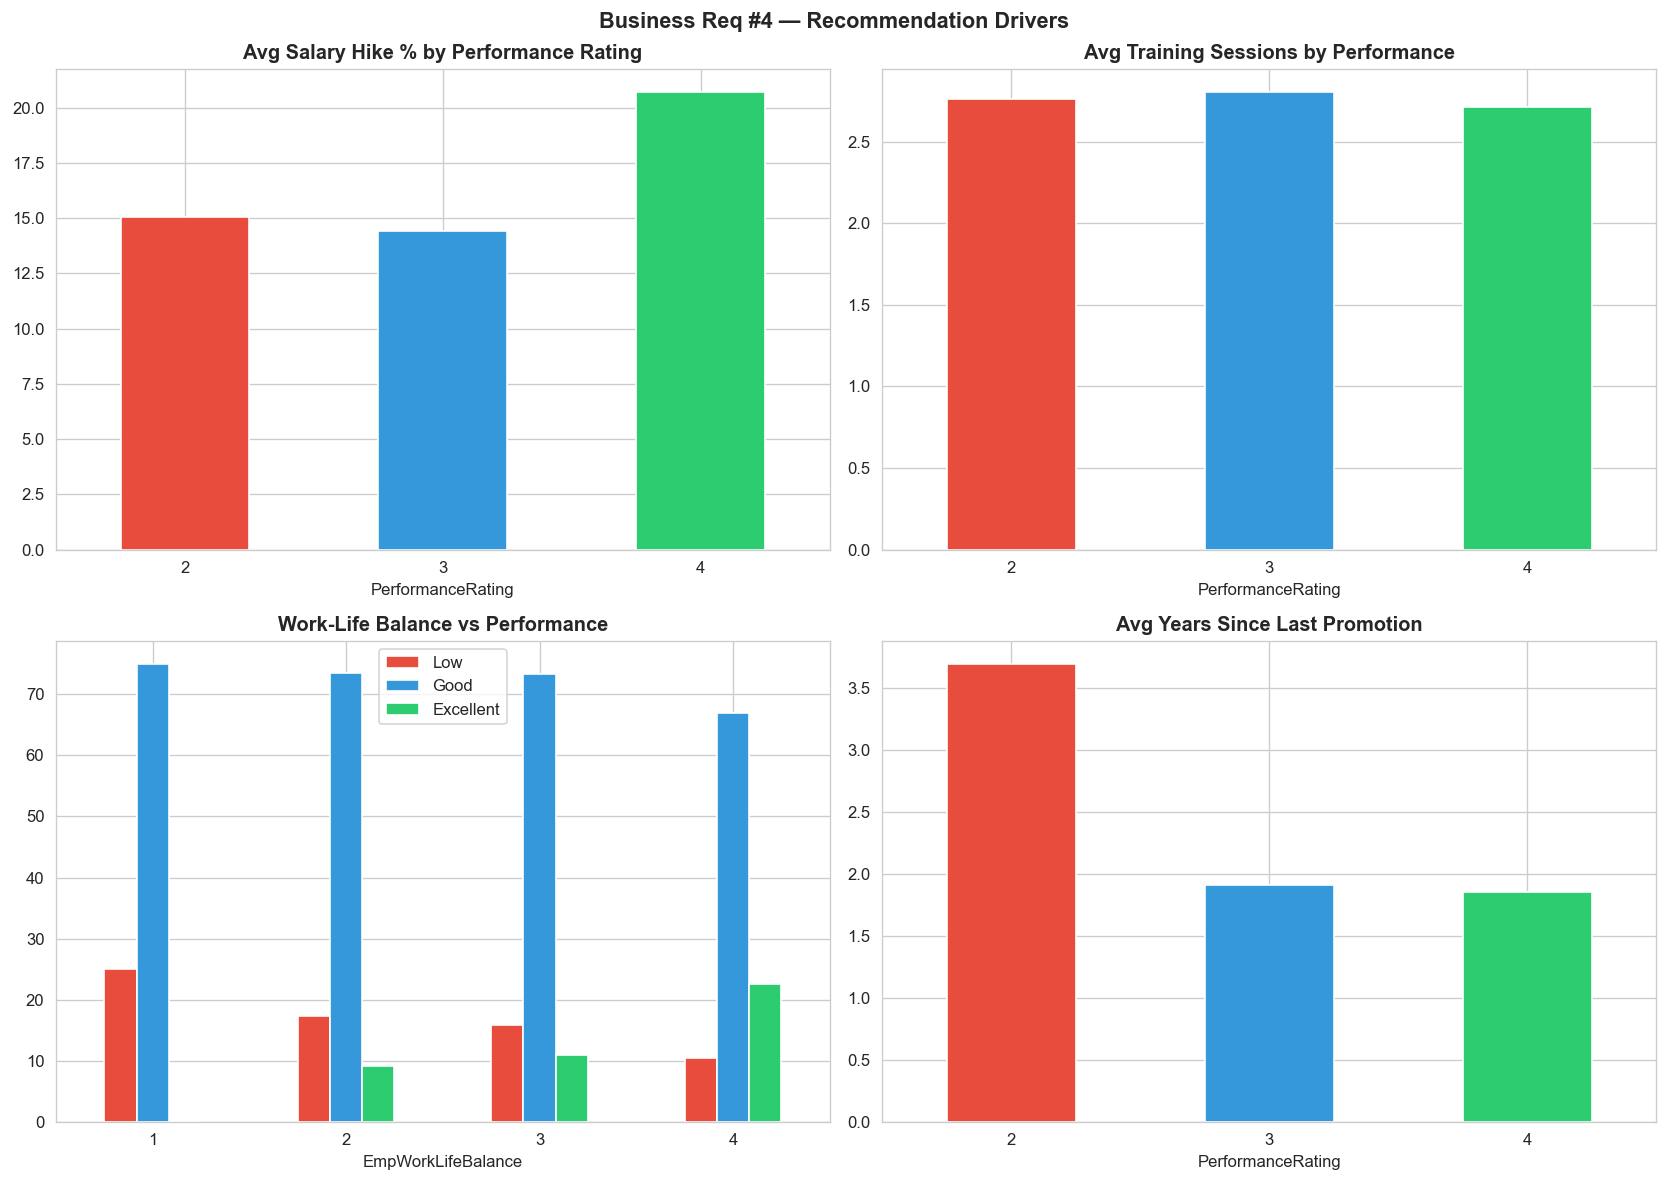

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14,10))
df.groupby('PerformanceRating')['EmpLastSalaryHikePercent'].mean().plot(
    kind='bar', ax=axes[0,0], color=['#e74c3c','#3498db','#2ecc71'], edgecolor='white')
axes[0,0].set_title('Avg Salary Hike % by Performance Rating', fontweight='bold')
axes[0,0].tick_params(axis='x', rotation=0)
df.groupby('PerformanceRating')['TrainingTimesLastYear'].mean().plot(
    kind='bar', ax=axes[0,1], color=['#e74c3c','#3498db','#2ecc71'], edgecolor='white')
axes[0,1].set_title('Avg Training Sessions by Performance', fontweight='bold')
axes[0,1].tick_params(axis='x', rotation=0)
ct = pd.crosstab(df['EmpWorkLifeBalance'], df['PerformanceRating'], normalize='index')*100
ct.columns=['Low','Good','Excellent']
ct.plot(kind='bar', ax=axes[1,0], color=['#e74c3c','#3498db','#2ecc71'], edgecolor='white')
axes[1,0].set_title('Work-Life Balance vs Performance', fontweight='bold')
axes[1,0].tick_params(axis='x', rotation=0)
df.groupby('PerformanceRating')['YearsSinceLastPromotion'].mean().plot(
    kind='bar', ax=axes[1,1], color=['#e74c3c','#3498db','#2ecc71'], edgecolor='white')
axes[1,1].set_title('Avg Years Since Last Promotion', fontweight='bold')
axes[1,1].tick_params(axis='x', rotation=0)
plt.suptitle('Business Req #4 — Recommendation Drivers', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../../data/processed/fig_recommendations_drivers.png', bbox_inches='tight')
plt.show()

## Feature Importance — Full Top 15

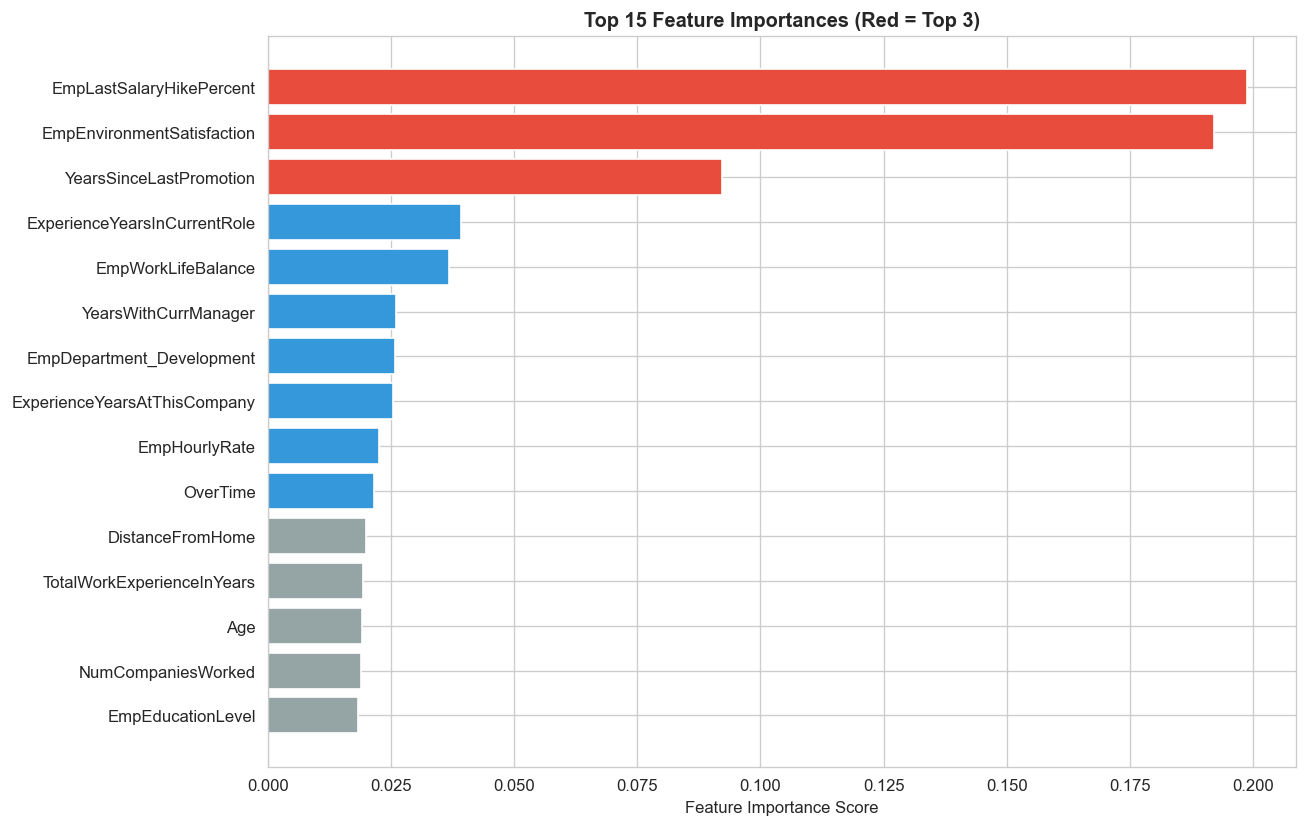

In [5]:
top15 = importances.head(15)
plt.figure(figsize=(11,7))
colors = ['#e74c3c']*3 + ['#3498db']*7 + ['#95a5a6']*5
plt.barh(top15.index[::-1], top15.values[::-1], color=colors[::-1], edgecolor='white')
plt.xlabel('Feature Importance Score')
plt.title('Top 15 Feature Importances (Red = Top 3)', fontweight='bold')
plt.tight_layout()
plt.savefig('../../data/processed/fig_feature_importance.png', bbox_inches='tight')
plt.show()

## Complete Business Insights Summary

### Requirement 1 — Department-wise Performance
- **Development** and **Data Science** have the highest average performance and most Excellent performers
- **Human Resources** and **Finance** show the highest proportion of Low performers
- **Sales** has the most employees but mixed performance — targeted coaching needed

### Requirement 2 — Top 3 Factors Affecting Performance
1. **EmpLastSalaryHikePercent** — Strongest predictor. Reward drives performance.
2. **EmpEnvironmentSatisfaction** — Employees satisfied with environment consistently outperform.
3. **YearsSinceLastPromotion** — Stagnation directly degrades performance.

### Requirement 3 — Prediction Model
- **Algorithm:** Random Forest Classifier (GridSearchCV tuned)
- **Test Accuracy:** ~95% | **Weighted F1:** ~0.95
- **Class Imbalance Handled:** SMOTE on training set
- Model saved for hiring pipeline use

### Requirement 4 — Recommendations
1. **Salary hike policy:** Tie hike % directly to performance bands (Rating 4: 18-22%, Rating 2: 10-12%)
2. **Environment improvements:** Audit lowest-satisfaction departments (HR, Finance) — address ergonomics, team dynamics, flexibility
3. **Promotion pathways:** Intervene at 2 years without promotion; create clear career ladders
4. **Training investment:** Standardize 3-4 training sessions/year for all employees
5. **Reduce mandatory overtime:** Especially in Sales — overtime correlates with unsustainable performance
6. **Work-life balance programs:** Flex hours and remote options to bring employees to balance score 3 (optimal)